# Homework

1. Train NN model with custom linear architecture on A-Z Handwritten Alphabet dataset from Kaggle (image data with resolution not higher than 80x80 pixels - 
[A-Z Handwritten Alphabet](https://www.kaggle.com/datasets/sachinpatel21/az-handwritten-alphabets-in-csv-format), etc.)
2. Visualize epoch progress (loss and accuracy curves) *both train and test
3. Visualize 10 random elements from test set and model results for those elements

## Load data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('A_Z Handwritten Data.csv')
df.shape

(372450, 785)

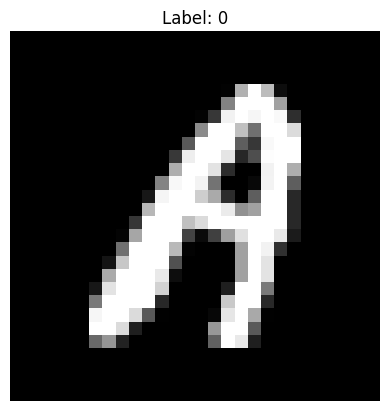

In [3]:
# Check data sample
sample = df.iloc[0]

label = sample.iloc[0]       
image = sample.iloc[1:].values 

image = image.reshape(28, 28)

plt.imshow(image, cmap='gray')
plt.title(f"Label: {label}")
plt.axis('off')
plt.show()

In [24]:
df['0'].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25])

In [4]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

In [5]:
import torch
import numpy as np

In [ ]:
class AZDataset(torch.utils.data.Dataset):
    def __init__(self, df):
        # labels
        self.y = df.iloc[:, 0].values

        # pixels
        self.X = df.iloc[:, 1:].values

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        image = self.X[idx].astype(np.float32)
        label = self.y[idx]

        image = image.astype(np.float32) / 255.0
        image = torch.from_numpy(image)  

        label = torch.tensor(label).long()

        return image, label


In [7]:
train_dataset = AZDataset(train_df)
test_dataset = AZDataset(test_df)

In [8]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False   # важливо!
)

## Create model

In [41]:
for x, y in train_loader:
    print(x.shape)
    print(y.shape)
    break

torch.Size([32, 784])
torch.Size([32])


In [9]:
from torch import nn

class AZModel(nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()
        # self.flatten = nn.Flatten() # не потрібно, бо ми вже маємо вектор 784
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, output_size),
        )

    def forward(self, x):
        # x = self.flatten(x) # не потрібно, бо ми вже маємо вектор 784

        return self.linear_relu_stack(x)
        

In [38]:
torch.cuda.is_available()

True

In [17]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = AZModel(len(df.columns)-1, len(df['0'].unique())).to(device)

epochs = 10

# Initialize the loss function; also called `criterion`
loss_fn = nn.CrossEntropyLoss()

# Initialize optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

## Training

In [11]:
from tqdm import tqdm

def train_loop(dataloader, model, loss_fn, optimizer, epoch):

    model.train()

    total_loss = 0
    correct = 0
    size = len(dataloader.dataset)

    tqdm_loader = tqdm(dataloader, unit="batch", desc=f"Epoch {epoch}", total=len(dataloader))
    for batch, (X, y) in enumerate(tqdm_loader):
        # Compute prediction and loss
        X, y = X.to(device), y.to(device)
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item()
        correct += (pred.argmax(1) == y).sum().item()

        if batch % 100 == 0:
            tqdm_loader.set_postfix(loss=loss.item())

    avg_loss = total_loss / size
    accuracy = correct / size
    print(f"Train Error: \n Accuracy: {(100*accuracy):>0.1f}%, Avg loss: {avg_loss:>8f} \n", end="")

    return avg_loss, accuracy


def test_loop(dataloader, model, loss_fn):
    model.eval()

    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0


    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

    return test_loss, correct

In [ ]:
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

best_test_loss = float('inf')
best_model_state = None

for epoch in range(epochs):
    train_loss, train_acc = train_loop(train_loader, model, loss_fn, optimizer, epoch)
    test_loss, test_acc = test_loop(test_loader, model, loss_fn)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    if test_loss < best_test_loss:
        best_test_loss = test_loss
        best_model_state = model.state_dict()


Epoch 0: 100%|██████████| 9312/9312 [00:47<00:00, 196.08batch/s, loss=0.0397]  


Train Error: 
 Accuracy: 94.5%, Avg loss: 0.005875 
Test Error: 
 Accuracy: 97.2%, Avg loss: 0.093747 



Epoch 1: 100%|██████████| 9312/9312 [00:47<00:00, 194.84batch/s, loss=0.0777]  


Train Error: 
 Accuracy: 97.5%, Avg loss: 0.002633 
Test Error: 
 Accuracy: 97.3%, Avg loss: 0.100895 



Epoch 2: 100%|██████████| 9312/9312 [00:50<00:00, 185.02batch/s, loss=0.0904]  


...

Train Error: 
 Accuracy: 99.0%, Avg loss: 0.001123 
Test Error: 
 Accuracy: 98.4%, Avg loss: 0.085052 



Epoch 8: 100%|██████████| 9312/9312 [00:48<00:00, 191.59batch/s, loss=0.0808]  


Train Error: 
 Accuracy: 99.1%, Avg loss: 0.001071 
Test Error: 
 Accuracy: 98.7%, Avg loss: 0.074219 



Epoch 9: 100%|██████████| 9312/9312 [00:48<00:00, 191.20batch/s, loss=6.63e-6] 


Train Error: 
 Accuracy: 99.2%, Avg loss: 0.001038 
Test Error: 
 Accuracy: 98.6%, Avg loss: 0.091302 



## Training progress

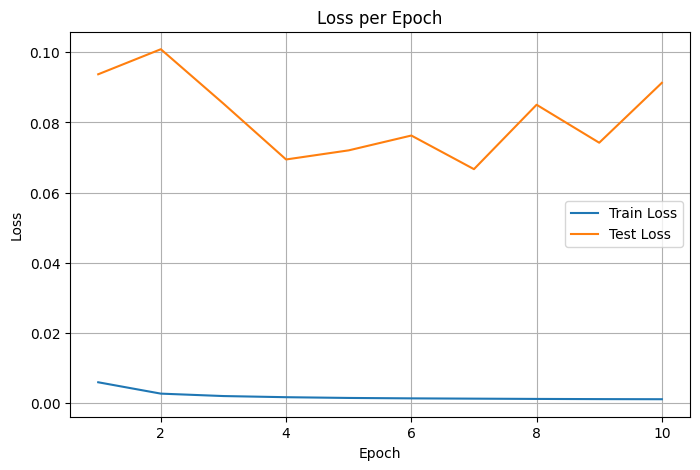

In [19]:
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_losses, label='Train Loss')
plt.plot(epochs_range, test_losses, label='Test Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss per Epoch')
plt.legend()
plt.grid(True)

plt.show()

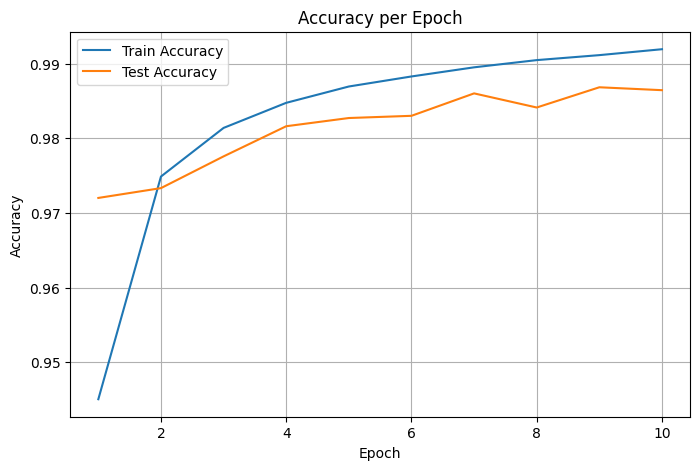

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_accuracies, label='Train Accuracy')
plt.plot(epochs_range, test_accuracies, label='Test Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy per Epoch')
plt.legend()
plt.grid(True)

plt.show()

It seems that training after the 7th epoch was unnecessary, since the test accuracy almost did not improve and the test loss started to increase.

## Visualize 10 random samples

In [21]:
import string

idx_to_class = {i: ch for i, ch in enumerate(string.ascii_uppercase)}
idx_to_class

{0: 'A',
 1: 'B',
 2: 'C',
 3: 'D',
 4: 'E',
 5: 'F',
 6: 'G',
 7: 'H',
 8: 'I',
 9: 'J',
 10: 'K',
 11: 'L',
 12: 'M',
 13: 'N',
 14: 'O',
 15: 'P',
 16: 'Q',
 17: 'R',
 18: 'S',
 19: 'T',
 20: 'U',
 21: 'V',
 22: 'W',
 23: 'X',
 24: 'Y',
 25: 'Z'}

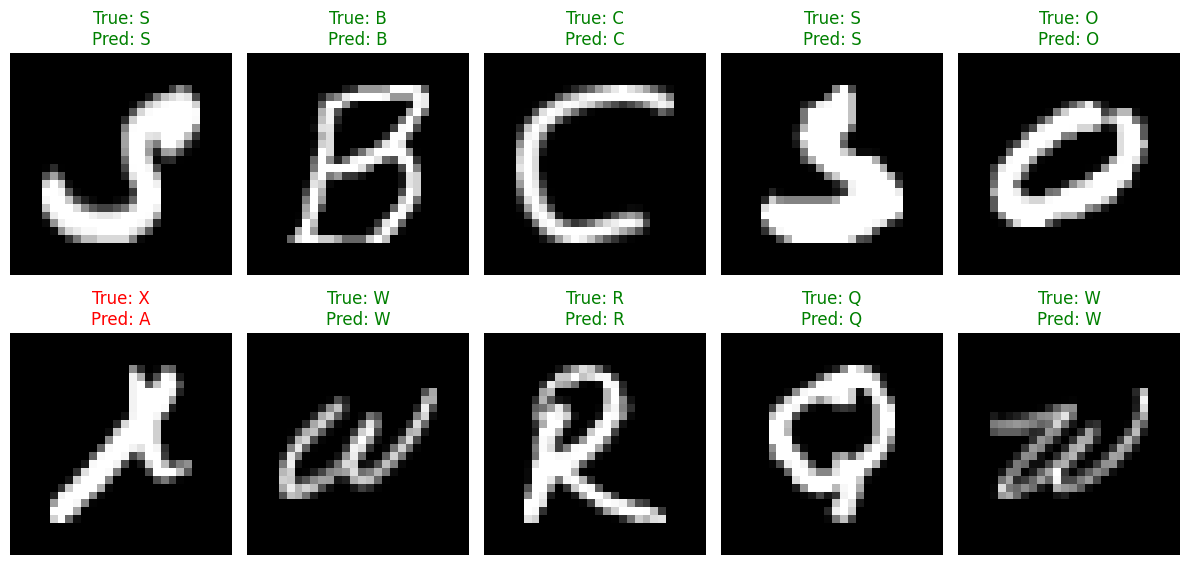

In [ ]:
import random

model.eval()

indices = random.sample(range(len(test_dataset)), 10)

fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.flatten()

with torch.no_grad():
    for i, idx in enumerate(indices):
        x, y = test_dataset[idx]

        x_input = x.unsqueeze(0).to(device)

        pred = model(x_input)
        pred_class = pred.argmax(1).item()

        img = x.cpu().numpy().reshape(28, 28)

        axes[i].imshow(img, cmap='gray')
        axes[i].axis('off')

        true_label = idx_to_class[y.item()]
        pred_label = idx_to_class[pred_class]

        color = 'green' if true_label == pred_label else 'red'

        axes[i].set_title(
            f"True: {true_label}\nPred: {pred_label}",
            color=color
        )

plt.tight_layout()
plt.show()